In [1]:
import numpy as np
from scipy.stats import ks_2samp
from scipy import stats
from scipy import stats
import matplotlib.pyplot as plt
import h5py
import illustris_python as il
import sys
sys.path.append('../../py_files/')
#import weights
import control_sample as control
import BRAHMA_python as il_brahma
from tqdm import tqdm

import host_galaxy_enhancement_plots as hostplot
import utils
from astropy.cosmology import Planck15
from astropy import units as u
import arepo_package as arepo

In [2]:
import scienceplots
plt.style.use(['science'])
import os
tex_path = '/apps/texlive/2023/bin/x86_64-linux/'
os.environ['PATH'] += os.pathsep + tex_path

In [3]:
TNG_basepath = '/orange/lblecha/IllustrisTNG/Runs/TNG50-1/output'
brahma_basepath="/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/SM5_TNG"

In [4]:
def z_to_tlookback(z):
    """Convert redshift to lookback time in Gyr using Planck15 cosmology."""
    return Planck15.lookback_time(z).value  # returns time in Gyr

In [5]:
def get_scale_factors(basePath, filename="output_scale_factors.txt"):
    path = basePath.split('/output')[0]
    #print(path)
    f = open(path+"/"+filename,'r')
    snaptimes = np.array([float(line) for line in f.readlines()])
    f.close()
    print(f"snapshot scale factors in {path}:")
    return snaptimes

In [6]:
TNG_scalefactors = get_scale_factors(TNG_basepath)
z = 1/TNG_scalefactors - 1                  
tlook_TNG = z_to_tlookback(z)
deltat_TNG = tlook_TNG[:-1]-tlook_TNG[1:]
snaps_TNG = np.arange(len(TNG_scalefactors))

snapshot scale factors in /orange/lblecha/IllustrisTNG/Runs/TNG50-1:


In [7]:
#brahma snapshots
snap,red = arepo.get_snapshot_redshift_correspondence(brahma_basepath)
brahma_tlook = z_to_tlookback(red)
brahma_deltat = brahma_tlook[:-1]-brahma_tlook[1:]

In [27]:
np.diff(brahma_tlook)

array([-0.00857377, -0.00809646, -0.00967724, -0.01150547, -0.01107909,
       -0.01454144, -0.01572576, -0.01700634, -0.02013539, -0.02384343,
       -0.02615352, -0.03334043, -0.03970924, -0.04744458, -0.05689119,
       -0.07235612, -0.09240054, -0.12407592, -0.16770201, -0.24532148,
       -0.36288629, -0.60464532, -1.13860855, -1.00809736, -1.58473691,
       -1.43587302, -1.27227523, -0.80246865, -0.909399  , -1.02374799,
       -1.14396449, -1.3363428 ])

In [20]:
red

array([2.50484387e+01, 2.39609608e+01, 2.30324872e+01, 2.20291718e+01,
       2.09634266e+01, 2.00464910e+01, 1.89776156e+01, 1.79630246e+01,
       1.69999610e+01, 1.60050415e+01, 1.49891732e+01, 1.40339921e+01,
       1.30025453e+01, 1.19802133e+01, 1.09756433e+01, 9.99659047e+00,
       9.00233985e+00, 8.01217295e+00, 7.00541705e+00, 6.01075740e+00,
       4.99593347e+00, 4.00794511e+00, 3.00813107e+00, 2.00202814e+00,
       1.49551217e+00, 9.97294226e-01, 7.00106354e-01, 5.03047523e-01,
       3.99926965e-01, 2.97717685e-01, 1.97284182e-01, 9.94018026e-02,
       2.22044605e-16])

In [24]:
z_to_tlookback(4.00794511e+00) - z_to_tlookback(4.99593347e+00)

-0.36288629190127786

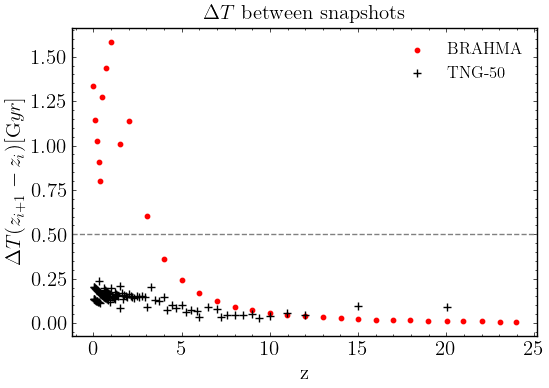

In [28]:
hostplot.set_plot_style(spinewidth=1, linewidth=1, titlesize=15, labelsize=15, xlabelsize=15, ylabelsize=15, legendsize=12, bold=True)
plt.figure(figsize=(6,4))
plt.scatter(red[1:],brahma_deltat,marker="o",s=10,c="red",label="BRAHMA")
plt.scatter(z[:-1],deltat_TNG,marker="+",c="k",label="TNG-50")
#plt.axhline(1,color="k",linestyle="--")
#plt.xlim(0,5)
plt.axhline(0.5,color="gray",linestyle="--")
plt.xlabel("z")
plt.title("$\Delta T$ between snapshots")
plt.legend()
plt.ylabel("$\Delta T (z_{i+1} - z_{i}) [\mathrm Gyr]$")
plt.savefig("../../figures/Brahma_vs_TNG50_time_delay.pdf")